# Population of Networks Test

In this experiment we create a population of neural networks of varying sizes.  We introduce defects into some of them and then use the equivalency test to identify the defects.  Statistics on equivalency test accuracy and runtime are extracted.



## Imports and Set up

In [1]:
%load_ext autoreload
%autoreload 2

from copy import deepcopy
import numpy as np
import pandas as pd
import pickle
import torch
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs
from prism.prism_math.multinomials import get_multinomial_coefs
from prism.analysis import test_statistics
from prism.analysis import boxplot_utils

import experiment_utils

torch.manual_seed(0)
np.random.seed(0)


## Get Coefficient Tables

In [2]:
(alpha_relu_coefs,
 alpha_relu_exponents,
 alpha_relu_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/relu_vmax7_bigm25_coefs_2021-01-23_20-03-01-218272.pickle')

alpha_relu_struct = experiment_utils.AlphaCoefsStruct(
    alpha_relu_coefs, alpha_relu_exponents, alpha_relu_coefs_float64)

(alpha_tanh_coefs,
 alpha_tanh_exponents,
 alpha_tanh_coefs_float64) = get_alpha_coefs(
    load_file='../prism/src/prism/coefs/tanh_vmax7_bigm25_coefs_2021-01-23_20-00-15-944616.pickle')

alpha_tanh_struct = experiment_utils.AlphaCoefsStruct(
    alpha_tanh_coefs, alpha_tanh_exponents, alpha_tanh_coefs_float64)

alpha_dict = {
    'relu': alpha_relu_struct,
    'tanh': alpha_tanh_struct
}

# Get some multinomial coefficient tables
mc_table_m_eq_2 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_2_n_0-400_2021-01-10_20-18-35-914937.pickle')

mc_table_m_eq_3 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_3_n_0-400_2021-01-10_20-19-13-878901.pickle')

mc_table_m_eq_4 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_4_n_0-150_2021-01-31_14-46-34-668685.pickle')

mc_table_m_eq_5 = get_multinomial_coefs(
    load_file='../prism/src/prism/coefs/multinomial_coefs_m_5_n_0-70_2021-01-31_15-19-30-353214.pickle')

mc_dict = {
    2: mc_table_m_eq_2,
    3: mc_table_m_eq_3,
    4: mc_table_m_eq_4,
    5: mc_table_m_eq_5
}


## Get Population of Networks Under Test

Here we get a population of original networks.  That population is deep copied to make a population of implemented networks under test.  A set of
defects is introduced into the implemented networks.  Statistics about the defects are tracked.


In [3]:
n_per_group = 3
hidden_nodes_list = [5, 10, 35, 75, 125,]
inputs_list = [2, 3, 4]
activation_list = ['tanh', 'relu',]

(original_networks,
 original_metadata_df) = experiment_utils.get_population_of_networks(
    n_per_group, hidden_nodes_list, inputs_list, activation_list,
    lr=0.01, momentum=0.1, rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam', weight_decay=0.01
)

implemented_networks = deepcopy(original_networks)
implemented_metadata_df = deepcopy(original_metadata_df)

experiment_utils.introduce_random_defects(
    implemented_networks, implemented_metadata_df)

print('Implemented network metadata with shape {}'.format(implemented_metadata_df.shape))
implemented_metadata_df.head()

Implemented network metadata with shape (90, 23)


,activation,n_inputs,n_hidden,true_defect,fit_residual,test_snr,test_time,max_weight_perturbation,avg_weight_perturbation,numpy_seed,...,e_mae_psi,e_male_psi,e_asinh_direct,e_mse_direct,e_mae_direct,e_male_direct,e_asinh_true,e_mse_true,e_mae_true,e_male_true
0,tanh,2,5,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None
1,tanh,2,5,True,None,None,None,0.766843,0.160571,None,...,None,None,None,None,None,None,None,None,None,None
2,tanh,2,5,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None
3,relu,2,5,True,None,None,None,0.0579622,0.00328834,None,...,None,None,None,None,None,None,None,None,None,None
4,relu,2,5,False,None,None,None,0,0,None,...,None,None,None,None,None,None,None,None,None,None


## Blackbox Test the Population of Networks

Here we loop through the population of networks and apply a simulated blackbox test to each pair of original-implemented networks. We track defect statistics over the population.

In [4]:
# Test parameters
m_max = 5
weight_decay = 0.01
measurement_snr_list = [-20, -10, -1, 0, 1, 10, 20]
n_fuzz_points = 250
n_epochs = 5
lr = 1e-3
eps = 1e-8
n_repeats = 3


In [5]:
test_results = []

columns = [
    'snr',
    'best_accuracy_mse_direct',
    'best_accuracy_mae_direct',
    'best_accuracy_asinh_psi',
    'best_accuracy_male_psi',
    'best_threshold_mse_direct',
    'best_threshold_mae_direct',
    'best_threshold_asinh_psi',
    'best_threshold_male_psi',
]

individual_test_dfs = []

for repeat_idx in range(n_repeats):

    print('*** Processing full iteration amount {} of {}'.format(
            repeat_idx + 1, n_repeats))

    for snr_idx, measurement_snr in enumerate(measurement_snr_list):

        print('*** Processing SNR amount {} of {}'.format(
            snr_idx + 1, len(measurement_snr_list)))

        blackbox_test_metadata_df = deepcopy(implemented_metadata_df)

        experiment_utils.blackbox_test_population(
            original_networks, implemented_networks,
            blackbox_test_metadata_df,
            alpha_dict, mc_dict, m_max, make_plots=False,
            n_fuzz_points=n_fuzz_points, 
            measurement_snr=measurement_snr,
            n_epochs=n_epochs, weight_decay=weight_decay,
            lr=lr, eps=eps
        )

        (best_accuracy_mse_direct,
         best_threshold_mse_direct) = test_statistics.get_best_accuracy(
                blackbox_test_metadata_df, 'e_mse_direct', 0, 0.2, 30)

        (best_accuracy_mae_direct,
         best_threshold_mae_direct) = test_statistics.get_best_accuracy(
                blackbox_test_metadata_df, 'e_mae_direct', 0, 0.2, 30)

        (best_accuracy_asinh_psi,
         best_threshold_asinh_psi) = test_statistics.get_best_accuracy(
                blackbox_test_metadata_df, 'e_asinh_psi', 0, 0.2, 30)

        (best_accuracy_male_psi,
         best_threshold_male_psi) = test_statistics.get_best_accuracy(
                blackbox_test_metadata_df, 'e_male_psi', 0.1, 1.5, 30)

        test_results_row = [
            measurement_snr,
            best_accuracy_mse_direct,
            best_accuracy_mae_direct,
            best_accuracy_asinh_psi,
            best_accuracy_male_psi,
            best_threshold_mse_direct,
            best_threshold_mae_direct,
            best_threshold_asinh_psi,
            best_threshold_male_psi
        ]

        test_results.append(test_results_row)
        individual_test_dfs.append(blackbox_test_metadata_df)

test_results_df = pd.DataFrame(
    test_results, columns=columns
)

individual_tests_df = pd.concat(individual_test_dfs)

*** Processing full iteration amount 1 of 3
*** Processing SNR amount 1 of 7
Processed 1     / 90    in 2.229 s; e_male_psi = 0.22; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 2     / 90    in 1.790 s; e_male_psi = 0.51; e_mse_true = 0.09; e_mse_direct = 0.09;
Processed 3     / 90    in 1.770 s; e_male_psi = 0.40; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 4     / 90    in 1.537 s; e_male_psi = 0.22; e_mse_true = 0.01; e_mse_direct = 0.01;
Processed 5     / 90    in 1.547 s; e_male_psi = 0.18; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 6     / 90    in 1.592 s; e_male_psi = 1.23; e_mse_true = 0.20; e_mse_direct = 0.20;
Processed 7     / 90    in 3.745 s; e_male_psi = 0.52; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 8     / 90    in 3.684 s; e_male_psi = 0.21; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 9     / 90    in 3.787 s; e_male_psi = 0.22; e_mse_true = 0.00; e_mse_direct = 0.00;
Processed 10    / 90    in 2.998 s; e_male_psi = 1.86; e_mse_true = 

## Save the raw dataframe list for later

Each element of the dataframe list represents the results of one round of testing.   Here we save it off as a checkpoint before doing any post-processing.


In [6]:
save_df_list = True

if save_df_list:

    fname = experiment_utils.get_dated_filename('results/individual_test_dfs')
    fh = open(fname, 'wb')

    pickle.dump(individual_test_dfs, fh)
    

In [7]:
load_df_list = True

if load_df_list:

    fname = 'results/individual_test_dfs_2021-02-02_20-56-45-822592.pickle'
    fh = open(fname,'rb')
    individual_test_dfs = pickle.load(fh)

## 

## Save off the dataframes for later

Here we save off the aggregate dataframes as a checkpoint.


In [8]:
save_dfs = True

if save_dfs:

    test_results_df.to_pickle(
        experiment_utils.get_dated_filename('results/test_results'))

    individual_tests_df.to_pickle(
        experiment_utils.get_dated_filename('results/individual_tests'))


In [9]:
load_dfs = False

if load_dfs:

    test_results_df = pd.read_pickle('results/test_results_2021-02-01_22-59-45-078207.pickle')
    individual_tests_df = pd.read_pickle('results/individual_tests_2021-02-01_22-59-45-080176.pickle')


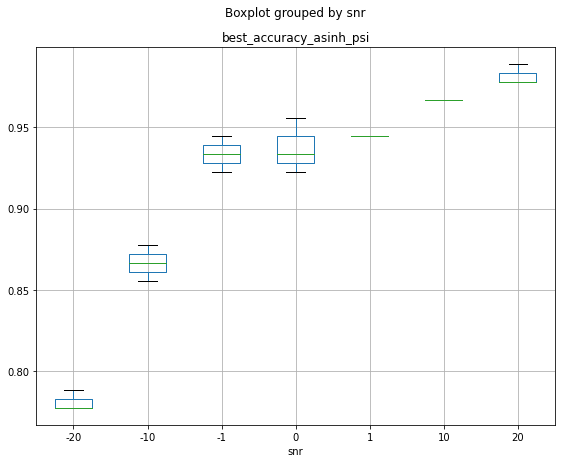

In [10]:
axs = test_results_df.boxplot(
    column='best_accuracy_asinh_psi',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

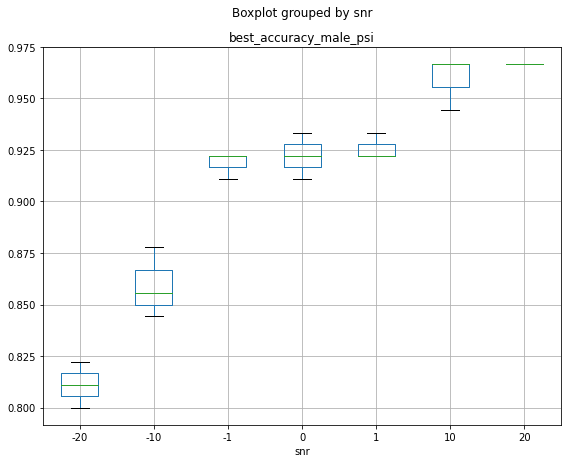

In [11]:
axs = test_results_df.boxplot(
    column='best_accuracy_male_psi',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

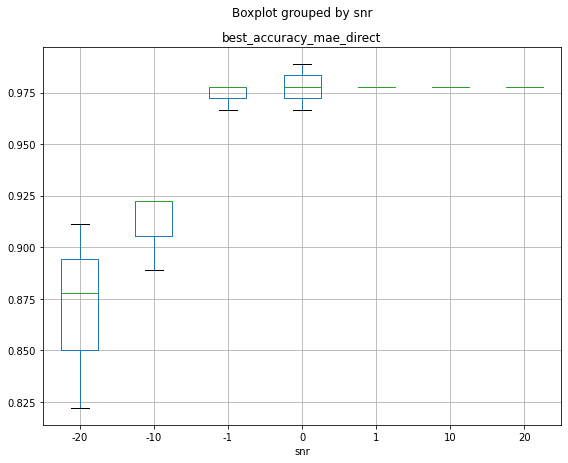

In [12]:
axs = test_results_df.boxplot(
    column='best_accuracy_mae_direct',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

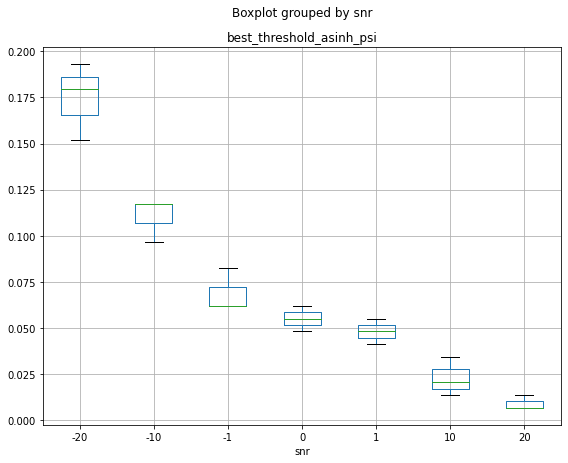

In [13]:
axs = test_results_df.boxplot(
    column='best_threshold_asinh_psi',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

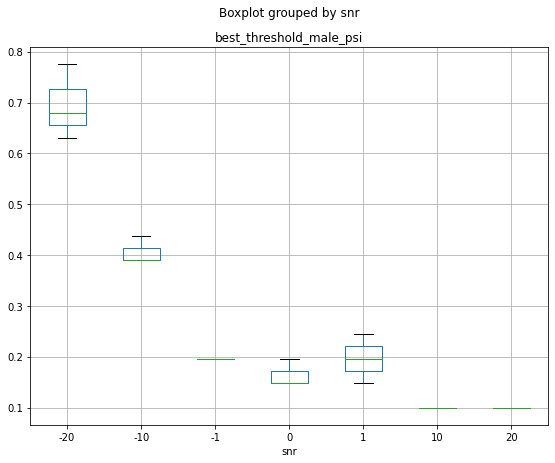

In [14]:
axs = test_results_df.boxplot(
    column='best_threshold_male_psi',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

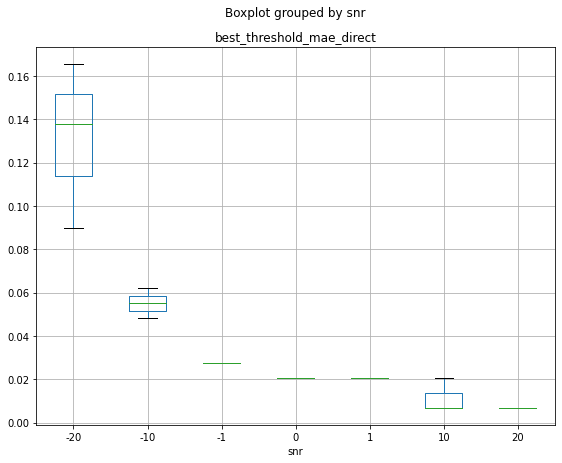

In [15]:
axs = test_results_df.boxplot(
    column='best_threshold_mae_direct',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

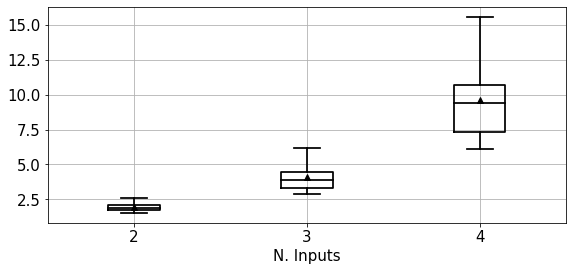

In [16]:
boxplot_utils.make_boxplot(
    'plots/runtime_wrt_num_inputs.png',
    individual_tests_df,
    xcol='n_inputs', ycol='test_time',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='N. Inputs')

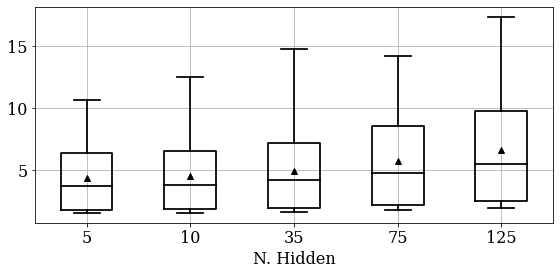

In [17]:
boxplot_utils.make_boxplot(
    'plots/runtime_wrt_n_hidden.png',
    individual_tests_df,
    xcol='n_hidden', ycol='test_time',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=16,
    xlabel='N. Hidden')

e_asinh_psi    AxesSubplot(0.1,0.15;0.8x0.75)
dtype: object

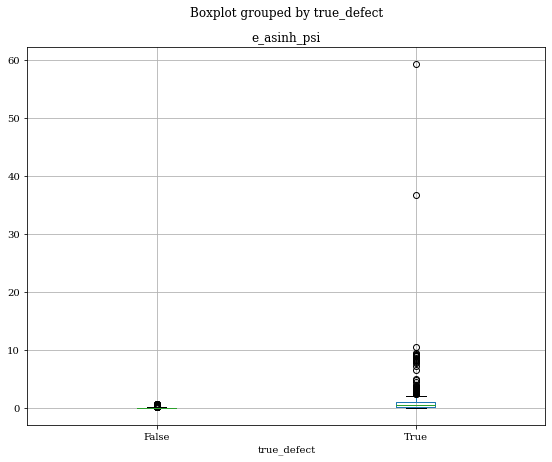

In [18]:
individual_tests_df.boxplot(
    column=['e_asinh_psi'],
    by='true_defect',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

e_male_psi    AxesSubplot(0.1,0.15;0.8x0.75)
dtype: object

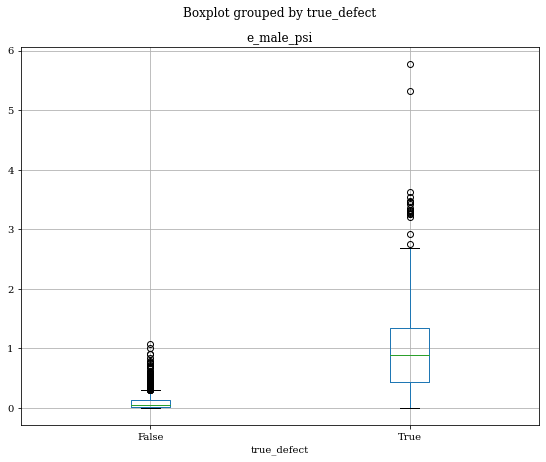

In [19]:
individual_tests_df.boxplot(
    column=['e_male_psi'],
    by='true_defect',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

e_mae_direct    AxesSubplot(0.1,0.15;0.8x0.75)
dtype: object

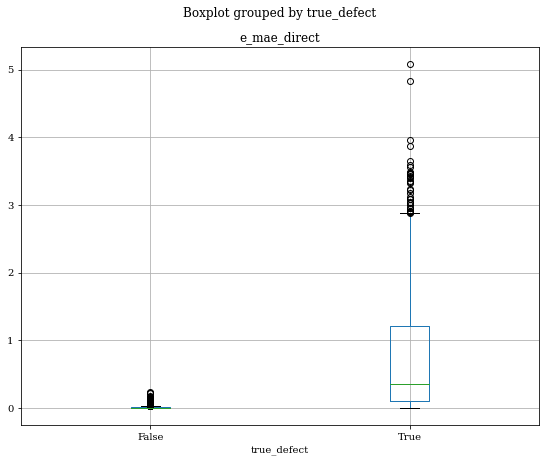

In [20]:
individual_tests_df.boxplot(
    column=['e_mae_direct',],
    by='true_defect',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

## Perform Post Processing on the dataframe list

Here we perform post processing on the dataframe list and save the results to the results dataframe.  We perform this step here so that we can set test settings informed by the raw results.


In [21]:
threshold_asinh_psi = 0.01
threshold_male_psi = 0.1
threshold_mae_direct = 0.01
threshold_mse_direct = 0.01

In [22]:
for idx, df in enumerate(individual_test_dfs):

    # Compute accuracies using the set thresholds and several methods
    accuracy_asinh_psi = test_statistics.compute_accuracy(df, 'e_asinh_psi', threshold_asinh_psi)
    accuracy_male_psi = test_statistics.compute_accuracy(df, 'e_male_psi', threshold_male_psi)
    accuracy_mae_direct = test_statistics.compute_accuracy(df, 'e_mae_direct', threshold_mae_direct)
    accuracy_mse_direct = test_statistics.compute_accuracy(df, 'e_mse_direct', threshold_mse_direct)

    # Add the new computed accuracies to the test results df in their own columns
    test_results_df.at[idx, 'accuracy_e_asinh_psi_threshold'] = accuracy_asinh_psi
    test_results_df.at[idx, 'accuracy_e_male_psi_threshold'] = accuracy_male_psi
    test_results_df.at[idx, 'accuracy_e_mae_direct_threshold'] = accuracy_mae_direct
    test_results_df.at[idx, 'accuracy_e_mse_direct_threshold'] = accuracy_mse_direct



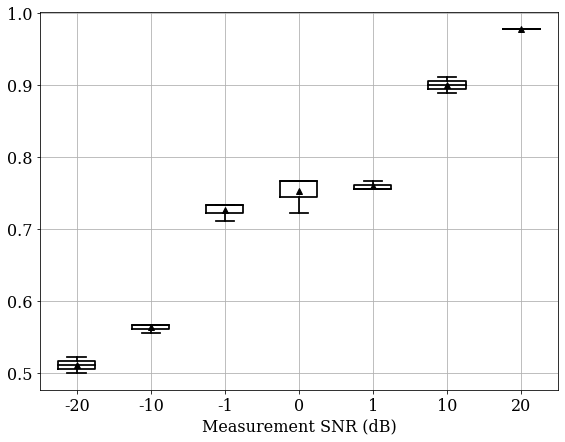

In [23]:
boxplot_utils.make_boxplot(
    'plots/accuracy_asinh_wrt_snr.png',
    test_results_df,
    xcol='snr', ycol='accuracy_e_asinh_psi_threshold',
    lw=1.75, color='k',
    figsize=(9,7), fontsize=16,
    xlabel='Measurement SNR (dB)')

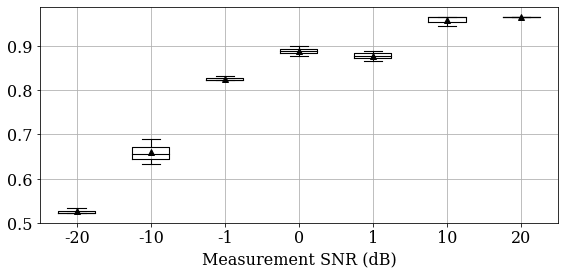

In [24]:
boxplot_utils.make_boxplot(
    'plots/accuracy_male_wrt_snr.png',
    test_results_df,
    xcol='snr', ycol='accuracy_e_male_psi_threshold',
    lw=1.1, color='k',
    figsize=(9,4), fontsize=16,
    xlabel='Measurement SNR (dB)')

In [25]:
boxplot_utils.make_boxplot(
    test_results_df,
    xcol='snr', ycol='accuracy_e_mae_direct_threshold',
    lw=1.75, color='k',
    figsize=(9,7), fontsize=16,
    xlabel='N. Hidden')

TypeError: make_boxplot() missing 1 required positional argument: 'df'

In [ ]:
axs = test_results_df.boxplot(
    column='accuracy_e_mse_direct_threshold',
    by='snr',
    figsize=(9,7),
    backend='matplotlib',
    return_type='axes')

In [ ]:
ax = plt.gca()

individual_tests_df.plot(
    y='e_male_psi',
    x='max_weight_perturbation',
    kind='scatter',
    figsize=(9,7),
    backend='matplotlib',
    color='red',
    ax=ax)

individual_tests_df.plot(
    y='e_mae_direct',
    x='max_weight_perturbation',
    kind='scatter',
    figsize=(9,7),
    backend='matplotlib',
    color='magenta',
    ax=ax)

individual_tests_df.plot(
    y='e_mse_direct',
    x='max_weight_perturbation',
    kind='scatter',
    figsize=(9,7),
    backend='matplotlib',
    color='blue',
    ax=ax)
